## 0. PREPARACIÓN DEL ENTORNO Y GESTIÓN DE RECURSOS

### 0.1. Protocolo *Clean Slate* (Purga de Memoria y Estado)
En entornos de ejecución iterativos (*Jupyter/Colab*), la memoria (RAM y VRAM de la GPU) así como el sistema de archivos retienen estados de ejecuciones previas. Si no se gestionan correctamente, esto provoca dos errores fatales en Machine Learning:
1.  **Fugas de Memoria (CUDA OOM):** Saturación de la tarjeta gráfica por tensores "huérfanos".
2.  **Contaminación de Checkpoints:** El objeto `Trainer` de Hugging Face puede intentar reanudar el entrenamiento desde un punto de control antiguo guardado en disco, arruinando la reproducibilidad del experimento.
Esta celda aplica una purga profunda forzando al recolector de basura (`gc`) y liberando la memoria caché de PyTorch para garantizar una ejecución determinista y 100% limpia.

In [ ]:
# ==========================================================
# CELDA 0: PURGA DE ENTORNO Y MEMORIA (CLEAN SLATE)
# ==========================================================
import os
import shutil
import gc
import torch

print("Iniciando purga profunda del entorno...")

# 1. PURGA DE DISCO (Evitar que el Trainer reanude un entrenamiento "fantasma")
directorios_a_borrar = [
    "./modelo_consumo_chatgpt",
    "./logs" # Por si en el futuro añadimos logs de TensorBoard
]

for dir_path in directorios_a_borrar:
    if os.path.exists(dir_path):
        shutil.rmtree(dir_path) # Equivalente a !rm -rf, pero seguro en Python
        print(f"[-] Directorio eliminado: {dir_path}")

# 2. PURGA DE MEMORIA RAM Y GPU (Evitar errores 'CUDA Out Of Memory')
# Borramos variables pesadas de la memoria de Python si existen de ejecuciones previas
try:
    del model, trainer, tokenized_train, tokenized_eval
except NameError:
    pass # Si no existen aún, no pasa nada

gc.collect() # Forzamos al recolector de basura de Python a actuar

if torch.cuda.is_available():
    torch.cuda.empty_cache() # Vaciamos la VRAM de la tarjeta gráfica
    print("[-] Memoria de la GPU liberada.")

print("- Entorno reseteado. Listo para una ejecución 100% limpia.")

Iniciando purga profunda del entorno...
[-] Memoria de la GPU liberada.
- Entorno reseteado. Listo para una ejecución 100% limpia.


## 1. PREPARACIÓN DEL STACK TECNOLÓGICO

### 1.1. Importación de Dependencias y Configuración del Entorno
Para el desarrollo de este TFG se ha seleccionado un ecosistema basado en **Python 3.x**, integrando las librerías líderes en Ciencia de Datos e Inteligencia Artificial:
* **Procesamiento y Matrices:** `Pandas` y `NumPy` para la manipulación de estructuras de datos.
* **Modelado de Lenguaje (NLP):** El ecosistema de `Hugging Face` (`Transformers` y `Datasets`) para gestionar la arquitectura RoBERTa.
* **Deep Learning:** `PyTorch` como motor de cómputo tensorial.
* **Evaluación y Métricas:** `Scikit-learn` para la validación científica y el particionado de datos.
* **Visualización:** `Matplotlib` y `Seaborn` para la interpretación gráfica de resultados.

In [ ]:
# ==========================================================
# CELDA 1.1: CONFIGURACIÓN, LIBRERÍAS Y DEPENDENCIAS
# ==========================================================
# 1. Procesamiento de datos y matemáticas
import pandas as pd
import numpy as np

# 2. IA y Deep Learning (Hugging Face & Torch)
import torch
from transformers import (
    pipeline,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from datasets import Dataset

# 3. Visualización y Gráficas
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Métricas de evaluación y validación científica
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# 5. Sistema y Google Drive
import os
from google.colab import drive # Omitir esta línea si usas PyCharm en local

# Configuración estética de las gráficas
plt.rcParams['figure.figsize'] = [10, 5]
sns.set_theme(style="whitegrid")

print("-Celda 1: Entorno de trabajo listo y optimizado.")

-Celda 1: Entorno de trabajo listo y optimizado.


## 2. PERSISTENCIA DE DATOS

### 2.1. Conexión a Repositorio y Definición de Rutas
Dado el volumen del *dataset* (190k registros), se utiliza **Google Drive** como sistema de almacenamiento persistente. Esto permite una gestión eficiente de los archivos CSV y garantiza que los modelos entrenados se guarden fuera de la memoria volátil de la instancia de Colab.

In [ ]:
# ==========================================================
# CELDA 2.1: CONEXIÓN A DRIVE Y DEFINICIÓN DE RUTAS
# ==========================================================
# Conectamos Google Drive (Solo necesario en Colab)
drive.mount('/content/drive')

# Definición de ruta única para la ingesta de texto
PATH_REVIEWS = '/content/drive/MyDrive/TFG_Inteligencia_Datos/Datasets/Mundo_B_ChatGPT/ChatGPT_Reviews.csv'

print(f"-Celda 2: Rutas configuradas. Apuntando a: {PATH_REVIEWS}")

Mounted at /content/drive
-Celda 2: Rutas configuradas. Apuntando a: /content/drive/MyDrive/TFG_Inteligencia_Datos/Datasets/Mundo_B_ChatGPT/ChatGPT_Reviews.csv


### 3.1. Ingesta y Estandarización del Dataset
En esta primera fase procedemos a la lectura del conjunto de datos en bruto. Para garantizar la interoperabilidad del código y facilitar su manipulación en la posterior etapa de visualización, se estandariza la nomenclatura de las columnas al español y a formato *snake_case*.

In [ ]:
# ==========================================================
# CELDA 3.1: INGESTA Y ESTANDARIZACIÓN
# ==========================================================
print("Cargando dataset de reviews de ChatGPT...")

df_reviews = pd.read_csv(PATH_REVIEWS)

# Renombramos columnas para estandarizar el acceso
df_reviews.rename(columns={
    'Review Id': 'id',
    'Review': 'texto',
    'Ratings': 'estrellas',
    'Review Date': 'fecha'
}, inplace=True)

print(f"Dataset cargado inicialmente con {len(df_reviews)} registros.")

Cargando dataset de reviews de ChatGPT...
Dataset cargado inicialmente con 196727 registros.


### 3.2. Aseguramiento de Calidad (Data QA) y Ordenación Temporal
La calidad del modelo depende directamente de la calidad de los datos ("*Garbage in, garbage out*"). Se aplica una limpieza estricta eliminando valores nulos y registros duplicados (potenciales bots o spam).
Además, dado que el objetivo final (Fase 3) es el análisis de series temporales, es crítico parsear y ordenar cronológicamente el *dataframe* desde este momento.

In [ ]:
# ==========================================================
# CELDA 3.2: LIMPIEZA FORENSE Y PARSEO DE FECHAS
# ==========================================================
total_inicial = len(df_reviews)

# Limpieza estricta: Borramos nulos y duplicados exactos
df_reviews.dropna(subset=['texto', 'estrellas', 'fecha'], inplace=True)
df_reviews.drop_duplicates(subset=['texto'], inplace=True)

# Parseo de Fechas y Ordenación Cronológica
df_reviews['fecha'] = pd.to_datetime(df_reviews['fecha'])
df_reviews = df_reviews.sort_values('fecha').reset_index(drop=True)

print(f"Limpieza completada: Pasamos de {total_inicial} a {len(df_reviews)} reseñas únicas y verificadas.")
print(f"Rango temporal del dataset: {df_reviews['fecha'].min()} hasta {df_reviews['fecha'].max()}")

Limpieza completada: Pasamos de 196727 a 125491 reseñas únicas y verificadas.
Rango temporal del dataset: 2023-07-25 15:01:00 hasta 2024-08-23 19:30:00


### 3.3. Ingeniería de Características (Target Variable)
Para adaptar el problema a la arquitectura de clasificación de la Inteligencia Artificial, transformamos la escala continua/ordinal de valoraciones (1 a 5 estrellas) en una variable categórica discreta de tres clases (Polaridad de Sentimiento):
* **-1 (Negativo):** 1 y 2 estrellas (Quejas y problemas).
* **0 (Neutro):** 3 estrellas (Ambivalencia o dudas).
* **1 (Positivo):** 4 y 5 estrellas (Satisfacción general).

In [ ]:
# ==========================================================
# CELDA 3.3: CREACIÓN DE LA ETIQUETA DE SENTIMIENTO
# ==========================================================
def mapear_estrellas_a_sentimiento(estrellas):
    if estrellas <= 2: return -1 # Quejas
    if estrellas == 3: return 0  # Neutro
    return 1                     # Positivo

# Aplicamos la función matemática para crear el Ground Truth
df_reviews['Sentimiento_Real'] = df_reviews['estrellas'].apply(mapear_estrellas_a_sentimiento)

print("Etiquetas de sentimiento generadas correctamente.")
display(df_reviews[['fecha', 'estrellas', 'Sentimiento_Real', 'texto']].head(3))

Etiquetas de sentimiento generadas correctamente.


,fecha,estrellas,Sentimiento_Real,texto
0,2023-07-25 15:01:00,5,1,I am the first one 😁😁
1,2023-07-25 15:01:00,4,1,What type this app
2,2023-07-25 15:02:00,5,1,Bahut Achcha work


## 4. PREPROCESAMIENTO Y BALANCEO

### 4.1. Muestreo Estratificado (Undersampling)
Uno de los retos más comunes en el análisis de sentimiento es el **desequilibrio de clases** (por ejemplo, tener muchas más reseñas positivas que neutras). Un modelo entrenado con datos desbalanceados tenderá a ignorar las clases minoritarias.
Para mitigar este sesgo, se aplica una técnica de *Undersampling* equilibrando el dataset a **5.000 muestras por clase**, creando así un conjunto de entrenamiento robusto de 15.000 registros donde cada polaridad tiene el mismo peso estadístico.

In [ ]:
# ==========================================================
# CELDA 4.1: MUESTREO ESTRATIFICADO (BALANCEO DE CLASES)
# ==========================================================
print("Balanceando el dataset para evitar sesgos en la IA...")

MUESTRAS_POR_CLASE = 5000

df_neg = df_reviews[df_reviews['Sentimiento_Real'] == -1]
df_neu = df_reviews[df_reviews['Sentimiento_Real'] == 0]
df_pos = df_reviews[df_reviews['Sentimiento_Real'] == 1]

# Evitamos errores si alguna clase tiene menos de 3000 reseñas
min_muestras = min(len(df_neg), len(df_neu), len(df_pos), MUESTRAS_POR_CLASE)

df_neg_sample = df_neg.sample(n=min_muestras, random_state=42)
df_neu_sample = df_neu.sample(n=min_muestras, random_state=42)
df_pos_sample = df_pos.sample(n=min_muestras, random_state=42)

# Unimos y barajamos (shuffle) para el entrenamiento
df_entrenamiento = pd.concat([df_neg_sample, df_neu_sample, df_pos_sample]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"-Celda 4: Dataset de entrenamiento listo: {len(df_entrenamiento)} reseñas balanceadas.")

Balanceando el dataset para evitar sesgos en la IA...
-Celda 4: Dataset de entrenamiento listo: 15000 reseñas balanceadas.


## FASE 1: JUSTIFICACIÓN DE ARQUITECTURA Y FINE-TUNING

### 5.1. Evaluación *Baseline* (Muestreo y Carga de Modelos)
Para garantizar el rigor científico del proyecto, antes de someter un modelo a *Fine-Tuning*, se realiza una evaluación *Zero-Shot* (sin entrenamiento previo sobre nuestros datos). Se extrae una muestra de control aleatoria y se instancian dos arquitecturas candidatas: un modelo genérico (BERT Multilingüe) y un modelo especializado en lenguaje coloquial (Twitter-RoBERTa).

In [ ]:
# ==========================================================
# CELDA 5.1: MUESTREO Y CARGA DE ARQUITECTURAS BASE
# ==========================================================
from transformers import pipeline
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

print("Iniciando Duelo de Modelos (Zero-Shot) con 150 reseñas de control...")

# 1. Extracción de muestra aleatoria para evaluación rápida
df_duelo = df_entrenamiento.sample(150, random_state=42).copy()
textos_duelo = df_duelo['texto'].tolist()
real = df_duelo['Sentimiento_Real'].tolist()

# 2. Instanciación de los motores en crudo (Pre-entrenados)
print("Cargando pipeline BERT (Multilingual)...")
pipe_bert = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment", truncation=True, max_length=128, device=0)

print("Cargando pipeline RoBERTa (Twitter Sentiment)...")
pipe_roberta = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment-latest", truncation=True, max_length=128, device=0)

Iniciando Duelo de Modelos (Zero-Shot) con 150 reseñas de control...
Cargando pipeline BERT (Multilingual)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

### 5.2. Homogeneización de Salidas e Inferencia
Dado que cada modelo pre-entrenado posee una topología de salida diferente (BERT devuelve una escala de 1 a 5 estrellas, mientras que RoBERTa devuelve etiquetas de texto), se aplican funciones de mapeo para estandarizar las predicciones a nuestra escala objetivo (-1, 0, 1) antes de ejecutar la inferencia.

In [ ]:
# ==========================================================
# CELDA 5.2: MAPEO E INFERENCIA ZERO-SHOT
# ==========================================================
# Mapeos auxiliares para igualar formatos a nuestra escala (-1, 0, 1)
def map_bert_zero(res):
    estrellas = int(res['label'][0])
    if estrellas <= 2: return -1
    if estrellas == 3: return 0
    return 1

def map_roberta_zero(res):
    label = res['label'].lower()
    if label == 'negative': return -1
    if label == 'neutral': return 0
    return 1

# Ejecución de Inferencia
print("BERT está evaluando la muestra...")
res_bert = pipe_bert(textos_duelo)
df_duelo['pred_bert'] = [map_bert_zero(r) for r in res_bert]

print("Twitter-RoBERTa está evaluando la muestra...")
res_roberta = pipe_roberta(textos_duelo)
df_duelo['pred_roberta'] = [map_roberta_zero(r) for r in res_roberta]

BERT está evaluando la muestra...
Twitter-RoBERTa está evaluando la muestra...


### 5.3. Resultados del *Baseline* (Precisión Base)
Comparamos el rendimiento de ambos modelos en crudo frente al *Ground Truth* (Sentimiento Real). Este análisis dictaminará qué arquitectura posee la mejor comprensión semántica base y, por ende, cuál será seleccionada para la fase de optimización o *Fine-Tuning*.

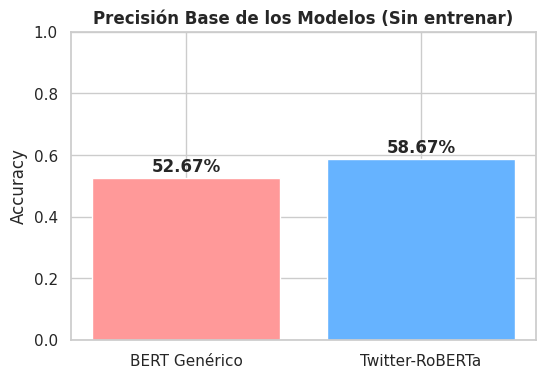


Celda 5: Duelo finalizado. RoBERTa se consolida como la arquitectura óptima.


In [ ]:
# ==========================================================
# CELDA 5.3: EVALUACIÓN VISUAL DEL DUELO
# ==========================================================
# Calculamos precisión (Accuracy)
acc_bert = accuracy_score(real, df_duelo['pred_bert'])
acc_roberta = accuracy_score(real, df_duelo['pred_roberta'])

# Renderizado de resultados
plt.figure(figsize=(6, 4))
barras = plt.bar(['BERT Genérico', 'Twitter-RoBERTa'], [acc_bert, acc_roberta], color=['#ff9999','#66b3ff'])
plt.title('Precisión Base de los Modelos (Sin entrenar)', fontweight='bold')
plt.ylabel('Accuracy')
plt.ylim(0, 1.0)

# Añadir el número encima de la barra
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 0.02, f"{yval:.2%}", ha='center', fontweight='bold')

plt.show()

print("\nCelda 5: Duelo finalizado. RoBERTa se consolida como la arquitectura óptima.")

### 6.1. Acondicionamiento Matemático y Particionado (Split)
Las redes neuronales basadas en PyTorch requieren que las etiquetas de clasificación comiencen en el índice 0. Por ello, se aplica una traslación matemática al *Ground Truth* (pasando de la escala [-1, 0, 1] a [0, 1, 2]).
A continuación, se divide el *dataset* utilizando un muestreo estratificado (80% entrenamiento, 20% validación) para asegurar que la proporción de clases se mantenga idéntica en ambos subconjuntos, garantizando una evaluación justa.

In [ ]:
# ==========================================================
# CELDA 6.1: PREPARACIÓN DE ETIQUETAS Y TRAIN/TEST SPLIT
# ==========================================================
from sklearn.model_selection import train_test_split

# 1. Adaptación matemática (PyTorch CrossEntropyLoss requiere 0, 1, 2)
df_entrenamiento['label'] = df_entrenamiento['Sentimiento_Real'] + 1

# 2. Particionado Estratificado (80% Entrenamiento / 20% Validación)
df_train, df_eval = train_test_split(
    df_entrenamiento,
    test_size=0.2,
    random_state=42,
    stratify=df_entrenamiento['label']
)

print(f"Set de Entrenamiento (Cerebro): {len(df_train)} reseñas.")
print(f"Set de Validación (Examen): {len(df_eval)} reseñas.")

Set de Entrenamiento (Cerebro): 12000 reseñas.
Set de Validación (Examen): 3000 reseñas.


### 6.2. Tokenización y Transformación a Tensores
Para que el modelo Transformer pueda procesar el texto, este debe ser traducido a tensores numéricos. Se instancia el tokenizador nativo de *Twitter-RoBERTa* y se establece un `max_length` de 256 tokens. Esta longitud ampliada (frente a los 128 estándar) se configuró tras detectar en iteraciones previas que las reseñas de consumo a menudo contienen el núcleo del sentimiento (ej. una queja) en los párrafos finales.

In [ ]:
# ==========================================================
# CELDA 6.2: TOKENIZACIÓN Y HUGGING FACE DATASETS
# ==========================================================
from transformers import AutoTokenizer
from datasets import Dataset

print("Cargando el tokenizador de la arquitectura ganadora...")
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Conversión del DataFrame de Pandas al formato Dataset de Hugging Face
dataset_train = Dataset.from_pandas(df_train[['texto', 'label']])
dataset_eval = Dataset.from_pandas(df_eval[['texto', 'label']])

# Función de tokenización (Padding y Truncation)
def tokenize_function(examples):
    # Ampliamos a 256 para capturar reseñas largas de usuarios frustrados
    return tokenizer(examples["texto"], padding="max_length", truncation=True, max_length=256)

print("Traduciendo el texto a tensores numéricos...")
tokenized_train = dataset_train.map(tokenize_function, batched=True)
tokenized_eval = dataset_eval.map(tokenize_function, batched=True)

print("\n✅ Celda 6: Datos vectorizados y listos para inyectar en el modelo.")

Cargando el tokenizador de la arquitectura ganadora...
Traduciendo el texto a tensores numéricos...


Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]


✅ Celda 6: Datos vectorizados y listos para inyectar en el modelo.


## 7. FASE DE OPTIMIZACIÓN Y ENTRENAMIENTO (FINE-TUNING)

### 7.1. Configuración del Motor y Ejecución del Aprendizaje
En esta etapa central del proyecto, se adapta la arquitectura base de *Twitter-RoBERTa* a nuestra topología específica de 3 clases. Para garantizar un aprendizaje robusto y evitar los problemas de inestabilidad detectados en iteraciones iniciales, se aplica una receta de hiperparámetros optimizada en un único bloque de ejecución:

1. **Métricas Científicas:** El modelo se autoevalúa priorizando el **F1-Score (Macro)** para garantizar equidad en el aprendizaje de las tres clases, mitigando posibles sesgos.
2. **Estabilización del Aprendizaje:** Se reduce el *Learning Rate* a `1e-5` y se aplica una Acumulación de Gradientes (`gradient_accumulation_steps=2`) para suavizar la convergencia de la red neuronal.
3. **Mecanismo Anti-Overfitting:** Se implementa un *Early Stopping* con paciencia de 3 pasos. Si la IA deja de mejorar su comprensión semántica en el set de validación, el entrenamiento se aborta automáticamente, salvaguardando la versión más inteligente de los pesos matemáticos.

In [ ]:
# ==========================================================
# CELDA 7.1: FINE-TUNING (EL MOTOR DEL TFG - CORREGIDO)
# ==========================================================
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

print("Descargando el cerebro base...")
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

# Función científica para que el modelo se evalúe a sí mismo
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average='macro')
    }

# Hiperparámetros Optimizados para la inestabilidad
training_args = TrainingArguments(
    output_dir="./modelo_consumo_chatgpt_v2",
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,   # <--- NUEVO: Estabiliza la curva de aprendizaje
    eval_strategy="steps",
    eval_steps=100,
    logging_strategy="steps",        # <--- NUEVO: Para que pinte la línea azul completa
    logging_steps=100,               # <--- NUEVO
    save_strategy="steps",
    save_steps=100,
    learning_rate=1e-5,              # <--- REDUCIDO: De 2e-5 a 1e-5 para aprender con más calma
    warmup_ratio=0.1,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)] # Freno de emergencia
)

print("INICIANDO ENTRENAMIENTO... (Esto tardará unos minutos)")
trainer.train()

print("\nCelda 7: ¡Entrenamiento completado!")

Descargando el cerebro base...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


INICIANDO ENTRENAMIENTO... (Esto tardará unos minutos)


Step,Training Loss,Validation Loss,Accuracy,F1
100,1.733183,0.766055,0.659333,0.656576
200,1.521989,0.731946,0.688000,0.678801
300,1.520670,0.717580,0.681333,0.683401


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Celda 7: ¡Entrenamiento completado!


### 7.2. Curvas de Aprendizaje y Diagnóstico de Salud del Modelo
Para validar empíricamente que el modelo ha generalizado correctamente sin caer en la memorización de los datos (*Overfitting*), se extrae el registro telemétrico (*log history*) del entrenamiento.
Al graficar la Pérdida de Entrenamiento (*Train Loss*) frente a la Pérdida de Validación (*Eval Loss*), buscamos confirmar dos hitos:
1.  **Convergencia:** Ambas curvas deben tener una tendencia descendente.
2.  **Estabilidad:** La curva de validación no debe rebotar violentamente hacia arriba (lo que indicaría un ajuste excesivo a los datos de entrenamiento). La actuación del *Early Stopping* garantiza que nos quedemos en el valle óptimo de esta gráfica.

Extrayendo historial de entrenamiento para validación científica...


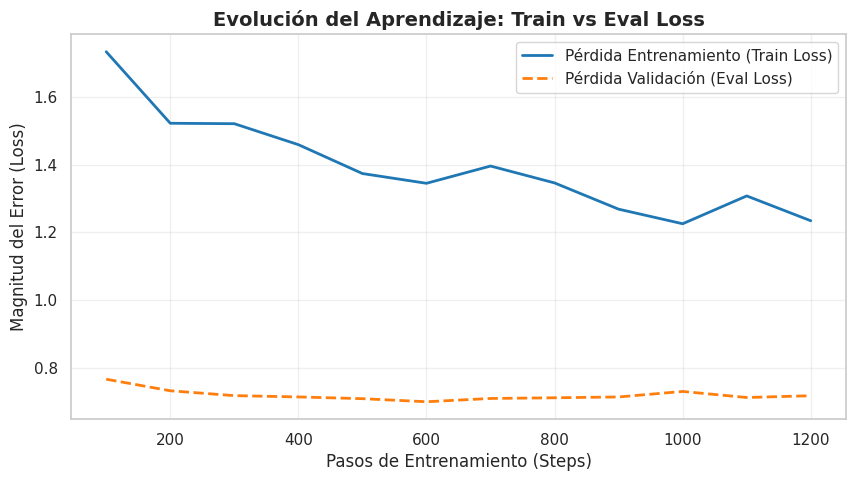

✅ Gráfica generada. Una curva descendente y paralela indica un aprendizaje sano.


In [ ]:
# ==========================================================
# CELDA 7.2: CURVAS DE APRENDIZAJE (LOGS DE ENTRENAMIENTO)
# ==========================================================
import matplotlib.pyplot as plt

print("Extrayendo historial de entrenamiento para validación científica...")

# Recuperamos los logs del trainer
history = trainer.state.log_history

# Filtramos los datos de entrenamiento y evaluación
train_loss = [x['loss'] for x in history if 'loss' in x]
train_steps = [x['step'] for x in history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
eval_steps = [x['step'] for x in history if 'eval_loss' in x]

# Graficamos la evolución del error (Loss)
plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_loss, label='Pérdida Entrenamiento (Train Loss)', color='#1f77b4', linewidth=2)
plt.plot(eval_steps, eval_loss, label='Pérdida Validación (Eval Loss)', color='#ff7f0e', linestyle='--', linewidth=2)

plt.title('Evolución del Aprendizaje: Train vs Eval Loss', fontsize=14, fontweight='bold')
plt.xlabel('Pasos de Entrenamiento (Steps)', fontsize=12)
plt.ylabel('Magnitud del Error (Loss)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("✅ Gráfica generada. Una curva descendente y paralela indica un aprendizaje sano.")

## 8. EVALUACIÓN DE RENDIMIENTO Y ANÁLISIS DE ERRORES

### 8.1. Informe de Clasificación y Matriz de Confusión
Tras finalizar el entrenamiento y asegurar los pesos óptimos del modelo, se procede a su evaluación final utilizando el subconjunto de Validación (el 20% de datos aislados previamente).
Para auditar el modelo se utilizan dos herramientas estándar en la industria:
1.  **Classification Report:** Desglosa la Precisión, *Recall* y *F1-Score* por cada clase. Nos permite confirmar que el modelo no sufre de sesgos graves y que el rendimiento macro (promedio) es simétrico.
2.  **Matriz de Confusión:** Una representación térmica (*Heatmap*) que enfrenta las etiquetas reales contra las predicciones de la IA. Es vital para entender la topología del error (por ejemplo, verificar que los errores se dan en clases adyacentes, como confundir "Neutro" con "Positivo", y no en errores catastróficos diametralmente opuestos).

Generando predicciones finales sobre el set de validación...



INFORME DE RENDIMIENTO TÉCNICO (IA)
              precision    recall  f1-score   support

    Negativo       0.74      0.74      0.74      1000
      Neutro       0.63      0.57      0.59      1000
    Positivo       0.72      0.80      0.76      1000

    accuracy                           0.70      3000
   macro avg       0.70      0.70      0.70      3000
weighted avg       0.70      0.70      0.70      3000



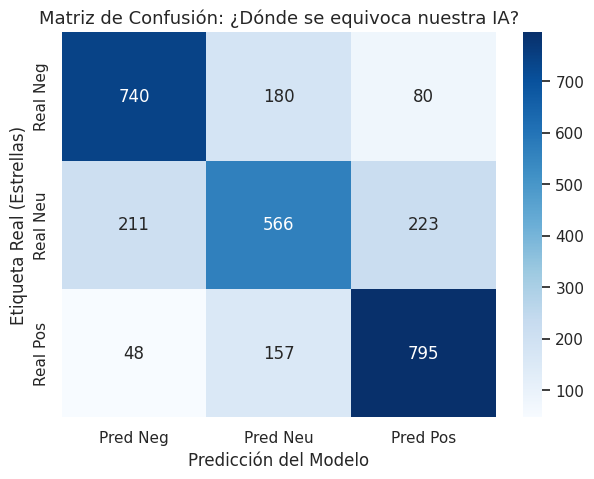

✅ Objetivo 4: Validación Científica completada con éxito.


In [ ]:
# ==========================================================
# CELDA 8: INFORME CIENTÍFICO Y MATRIZ DE CONFUSIÓN
# ==========================================================
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("Generando predicciones finales sobre el set de validación...")
# Obtenemos las predicciones del modelo sobre el dataset de evaluación
predictions = trainer.predict(tokenized_eval)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

# 1. Informe de métricas profesional
print("\n" + "="*60)
print("INFORME DE RENDIMIENTO TÉCNICO (IA)")
print("="*60)
print(classification_report(labels, preds, target_names=['Negativo', 'Neutro', 'Positivo']))

# 2. Matriz de Confusión (Visualización del Error)
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Neg', 'Pred Neu', 'Pred Pos'],
            yticklabels=['Real Neg', 'Real Neu', 'Real Pos'])

plt.title('Matriz de Confusión: ¿Dónde se equivoca nuestra IA?', fontsize=13)
plt.ylabel('Etiqueta Real (Estrellas)')
plt.xlabel('Predicción del Modelo')
plt.show()

print("✅ Objetivo 4: Validación Científica completada con éxito.")

## 9. EXPORTACIÓN Y PERSISTENCIA DEL MODELO (ARTEFACTO FINAL)

### 9.1. Serialización de Pesos y Tokenizador a Google Drive
Un modelo entrenado en un entorno *cloud* temporal (como Google Colab) se pierde al finalizar la sesión debido a la volatilidad de la memoria. Para integrar esta Inteligencia Artificial en el flujo de trabajo de la Fase 2 (Inferencia Masiva local en PyCharm), es estrictamente necesario persistir el "artefacto".
Mediante la función `save_pretrained`, se exportan tanto los pesos matemáticos de la red neuronal (el modelo) como el diccionario de vocabulario (el tokenizador) a una ruta segura en Google Drive, permitiendo su uso offline o su despliegue en producción.

In [ ]:
# ==========================================================
# CELDA 9: PERSISTENCIA DEL CEREBRO (GUARDADO EN DRIVE)
# ==========================================================
import os

# Definimos la ruta de guardado profesional
RUTA_MODELO_FINAL = "/content/drive/MyDrive/TFG_Inteligencia_Datos/Modelos/cerebro_consumo_v2"

if not os.path.exists(RUTA_MODELO_FINAL):
    os.makedirs(RUTA_MODELO_FINAL)

# Guardamos tanto el modelo como el tokenizador
model.save_pretrained(RUTA_MODELO_FINAL)
tokenizer.save_pretrained(RUTA_MODELO_FINAL)

print(f"Conocimiento persistido correctamente en: {RUTA_MODELO_FINAL}")
print("¡Fase 1 (El Cerebro) finalizada al 100%! Ya tienes el motor para tu dashboard.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Conocimiento persistido correctamente en: /content/drive/MyDrive/TFG_Inteligencia_Datos/Modelos/cerebro_consumo_v2
¡Fase 1 (El Cerebro) finalizada al 100%! Ya tienes el motor para tu dashboard.
